In [1]:
import os
os.chdir('../../..')

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import kmedoids
import chemiscope

from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from tqdm import tqdm
from umap import UMAP
from persim import plot_diagrams

from src.datasets import QM9Dataset
from src.features import MolecularFeaturizer
from src.non_euclidean import Grassmann, Riemann, PersistentHomology

In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_soap()

2026-03-18 08:36:51.904 | INFO     | src.datasets:load:381 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-18 08:36:51.922 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-18 08:37:03.605 | SUCCESS  | src.datasets:add_soap:599 - Added SOAP embeddings.


In [5]:
qm9.df.tail(3)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_130771""","""C4H5F3O2""","""[H]OC([H])([H])C([H])([H])C(=O…","""[H]OC([H])([H])C([H])([H])C(=O…","""[H][O][C][Branch1][C][H][Branc…","""alcohol,ketone,halogen""",14,"""Acyclic""",142,0,37,9,0,0,3,0.0,0.25,0.75,1,2,4,0,1,3,6,28,1.285363,0,1,0,0,0,0,0,1,0,0,5,2.1764,51.5,-7.630073,-1.431319,6.198753,1409.462402,2.573979,-16471.908203,-16471.650391,-16471.625,-16472.90625,31.788,-58.713444,-58.994862,-59.328938,-54.656414,3.19999,0.85416,0.77267,"[0.08307, 0.225292, … 0.096336]"
"""qm9_130787""","""C4H8F3NO""","""[H]N([H])[C@@]([H])(C(F)(F)F)C…","""[H]N([H])[C@@]([H])(C(F)(F)F)C…","""[H][N][Branch1][C][H][C@@][Bra…","""amine,ether,halogen""",17,"""Acyclic""",143,0,35,9,0,0,4,0.0,0.0,1.0,1,2,5,0,0,4,6,35,1.260184,0,0,0,1,0,0,0,0,1,0,5,3.0217,58.34,-6.870875,2.013643,8.881797,1413.532959,3.569018,-15963.179688,-15962.912109,-15962.885742,-15964.146484,34.320999,-66.454163,-66.841591,-67.252785,-61.493713,3.0464,0.89833,0.81121,"[0.108718, 0.291814, … 0.116882]"
"""qm9_130798""","""C7H10N2+2""","""[H]C1([H])[N@@H+]2[C@@]3([H])[…","""[H]C1([H])C23C([H])([H])[N@+]4…","""[H][C][Branch1][C][H][C][C][Br…","""""",17,"""Aliphatic Ring""",122,-3,8,9,4,0,0,0.0,0.0,1.0,2,0,9,0,0,7,5,45,1.287111,0,0,0,0,0,0,0,0,0,0,2,1.2297,73.779999,-6.196033,1.561934,7.757967,753.384827,3.796832,-10359.493164,-10359.348633,-10359.322266,-10360.287109,24.007999,-70.940796,-71.451912,-71.863098,-65.827103,3.42059,2.38003,2.00882,"[0.123113, 0.335751, … 0.0]"


In [6]:
row = 0
num_molecules = None

# add molecular formula to find isomers
df = qm9.df

min_isomers = 30
formula_counts = df.group_by("formula").len().sort("len", descending=True)

display(formula_counts.head(10))

eligible = formula_counts.filter(pl.col("len") >= min_isomers)
if eligible.is_empty():
    raise ValueError(f"No formulas found with at least {min_isomers} isomers")

target_formula = eligible.row(row)[0]

isomers_df = df.filter(pl.col("formula") == target_formula)

def format_chemical(formula):
    return re.sub(r'(\d+)', lambda m: m.group(1).translate(str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")), formula)

print(f"Selected formula: {format_chemical(target_formula)} (n={isomers_df.height})")

formula,len
str,u32
"""C7H10O2""",103
"""C8H12O""",66
"""C7H12O2""",58
"""C7H9NO""",55
"""C7H11NO""",52
"""C6H9NO2""",51
"""C8H14O""",50
"""C7H8O2""",38
"""C6H8O3""",38


Selected formula: C₇H₁₀O₂ (n=103)


In [7]:
isomers_df.head(5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_25439""","""C7H10O2""","""[H]OC1=C(C([H])(C([H])([H])[H]…","""[H]Oc1c(C([H])(C([H])([H])[H])…","""[H][O][C][=C][Branch2][Ring1][…","""phenol""",19,"""Aromatic""",126,2,33,9,1,1,4,0.0,0.571429,0.428571,1,2,7,0,4,3,6,38,1.256779,0,0,1,0,0,0,0,0,0,0,2,1.6032,78.879997,-5.33071,0.674842,6.005553,1226.895752,4.300841,-11512.025391,-11511.767578,-11511.741211,-11512.969727,34.719002,-81.630028,-82.103889,-82.566513,-76.091049,2.48409,1.31168,1.0558,"[0.121761, 0.328912, … 0.0]"
"""qm9_31771""","""C7H10O2""","""[H]OC([H])([H])C([H])([H])C1=C…","""[H]OC([H])([H])C([H])([H])c1c(…","""[H][O][C][Branch1][C][H][Branc…","""alcohol""",19,"""Aromatic""",126,1,33,9,1,1,4,0.0,0.571429,0.428571,1,2,7,0,4,3,7,37,1.24075,0,1,0,0,0,0,0,0,0,0,2,1.233,78.75,-5.700785,0.647631,6.348416,1455.962036,4.315917,-11511.998047,-11511.741211,-11511.71582,-11512.958008,33.782001,-81.602821,-82.078148,-82.540794,-76.079391,3.08314,0.96899,0.78139,"[0.122421, 0.330305, … 0.0]"
"""qm9_31825""","""C7H10O2""","""[H]OC1=C([H])OC(C([H])([H])C([…","""[H]Oc1c([H])oc(C([H])([H])C([H…","""[H][O][C][=C][Branch1][C][H][O…","""phenol""",19,"""Aromatic""",126,1,33,9,1,1,4,0.0,0.571429,0.428571,1,2,7,0,4,3,8,38,1.245244,0,0,1,0,0,0,0,0,0,0,2,1.982,79.620003,-5.387855,0.69389,6.081745,1659.569092,4.315345,-11512.020508,-11511.766602,-11511.740234,-11512.96875,34.035999,-81.624809,-82.102943,-82.565582,-76.09034,5.5212,0.74188,0.69022,"[0.122316, 0.33034, … 0.0]"
"""qm9_31884""","""C7H10O2""","""[H]OC([H])([H])C([H])([H])C1=C…","""[H]OC([H])([H])C([H])([H])c1oc…","""[H][O][C][Branch1][C][H][Branc…","""alcohol""",19,"""Aromatic""",126,1,33,9,1,1,4,0.0,0.571429,0.428571,1,2,7,0,4,3,8,37,1.240666,0,1,0,0,0,0,0,0,0,0,2,1.4796,80.410004,-5.57017,0.647631,6.220523,1576.102539,4.313385,-11512.129883,-11511.873047,-11511.84668,-11513.086914,33.799,-81.734848,-82.209854,-82.672493,-76.20813,4.01491,0.83179,0.7231,"[0.121823, 0.330908, … 0.0]"
"""qm9_36741""","""C7H10O2""","""[H]C1([H])OC([H])([H])[C@@]2([…","""[H]C1([H])OC([H])([H])[C@@]2([…","""[H][C][Branch1][C][H][O][C][Br…","""ether""",19,"""Aliphatic Ring""",126,0,18,9,4,0,0,0.0,0.0,1.0,0,2,7,0,0,7,5,41,1.277157,0,0,0,0,0,0,0,0,2,0,2,2.1474,73.07,-6.234128,1.844932,8.079061,901.112,4.441279,-11510.74707,-11510.568359,-11510.542969,-11511.581055,27.537001,-80.352074,-80.905396,-81.368042,-74.702606,2.51207,2.08674,1.65293,"[0.121553, 0.334067, … 0.0]"


In [8]:
original_df = qm9.df
qm9.df = isomers_df
frames = qm9.get_positions(
    subset_size=isomers_df.height,
    output_filename="qm9_isomers.xyz"
)
qm9.df = original_df

print(f"Generated {len(frames)} frames for isomer set")

2026-03-18 08:37:37.387 | SUCCESS  | src.datasets:get_positions:885 - Saved 103 molecules to data/QM9/qm9_isomers.xyz (failed: 0, requested: 103).


Generated 103 frames for isomer set


In [9]:
# grassmann distance on ASE frames
grassmann_dist = Grassmann.distance_matrix(frames)
riemann_dist = Riemann.distance_matrix(frames, 'affine-invariant')
ph_dist = PersistentHomology.distance_matrix(frames, 'sliced-wasserstein')

# SOAP features from SMILES
soap_series = MolecularFeaturizer.compute_soap(isomers_df["canonical_smiles"])
soap_list = soap_series.to_list()

valid_idx = [i for i, v in enumerate(soap_list) if v is not None]

if len(valid_idx) < 3:
    raise ValueError("Too few valid SOAP features to cluster")

isomers_df = isomers_df[valid_idx]

frames = [frames[i] for i in valid_idx]
grassmann_dist = grassmann_dist[np.ix_(valid_idx, valid_idx)]

2026-03-18 08:37:39.681 | INFO     | src.non_euclidean:distance_matrix:337 - Computing Grassmann distance matrix for 103 frames (k=3, method='svd', normalized=False).
Grassmann distances: 100%|██████████| 5253/5253 [00:00<00:00, 13079.40pair/s]
2026-03-18 08:37:40.182 | SUCCESS  | src.non_euclidean:distance_matrix:351 - Finished Grassmann distance matrix computation.
2026-03-18 08:37:40.182 | INFO     | src.non_euclidean:distance_matrix:460 - Computing Riemannian distance matrix for 103 frames (metric='affine-invariant', normalized=False)
Riemann distances: 100%|██████████| 5253/5253 [00:00<00:00, 52544.08pair/s]
2026-03-18 08:37:40.350 | SUCCESS  | src.non_euclidean:distance_matrix:524 - Finished Riemannian distance matrix computation.
2026-03-18 08:37:40.350 | INFO     | src.non_euclidean:distance_matrix:262 - Computing persistent homology distance matrix for 103 frames (metric='sliced-wasserstein', max_homology_dim=2, dims=(0, 1, 2)).
2026-03-18 08:37:40.350 | INFO     | src.non_euc

In [10]:
soap_dist = squareform(pdist(soap_list, metric='cosine'))

In [11]:
def evaluate_clustering_methods(distance_matrices, k_range=range(2, 15), random_state=42):
    results = {name: {"inertia": [], "silhouette": [], "ch": []} for name in distance_matrices}

    for k in tqdm(k_range, desc="Testing Cluster Counts"):
        for name, dist_matrix in distance_matrices.items():
            
            model = kmedoids.KMedoids(n_clusters=k, metric="precomputed", random_state=random_state)
            labels = model.fit_predict(dist_matrix)
            medoid_indices = model.medoid_indices_
            
            inertia = sum(dist_matrix[i, medoid_indices[labels[i]]] for i in range(len(labels)))
            
            sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            
            ch = calinski_harabasz_score(dist_matrix, labels)

            results[name]["inertia"].append(inertia)
            results[name]["silhouette"].append(sil)
            results[name]["ch"].append(ch)
            
    return results

matrices = {
    "Grassmann": grassmann_dist,
    "Riemann": riemann_dist,
    "SOAP": soap_dist,
    "Persistent Homology": ph_dist  
}
k_range = range(2, 15)
evaluation_results = evaluate_clustering_methods(matrices, k_range)

Testing Cluster Counts: 100%|██████████| 13/13 [00:00<00:00, 177.82it/s]


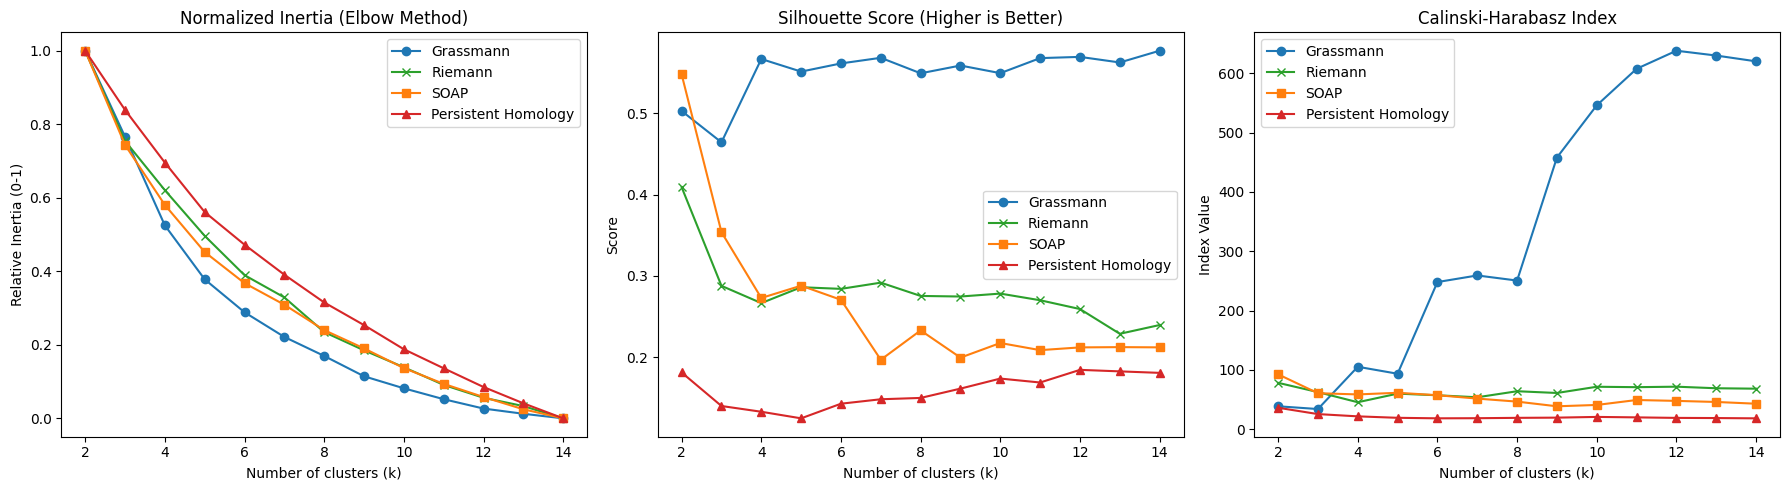

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Grassmann': 'tab:blue', 'Riemann': 'tab:green', 
          'SOAP': 'tab:orange', 'Persistent Homology': 'tab:red'}
markers = {'Grassmann': 'o', 'Riemann': 'x', 
           'SOAP': 's', 'Persistent Homology': '^'}

ax0 = axes[0]
for name in evaluation_results:
    raw_inertia = np.array(evaluation_results[name]["inertia"])
    norm_inertia = (raw_inertia - raw_inertia.min()) / (raw_inertia.max() - raw_inertia.min())
    
    ax0.plot(k_range, norm_inertia, label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax0.set_title('Normalized Inertia (Elbow Method)')
ax0.set_xlabel('Number of clusters (k)')
ax0.set_ylabel('Relative Inertia (0-1)')
ax0.legend()

ax1 = axes[1]
for name in evaluation_results:
    ax1.plot(k_range, evaluation_results[name]["silhouette"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax1.set_title('Silhouette Score (Higher is Better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Score')
ax1.legend()

ax2 = axes[2]
for name in evaluation_results:
    ax2.plot(k_range, evaluation_results[name]["ch"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax2.set_title('Calinski-Harabasz Index')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Index Value')
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
evaluation_results.keys()

Number of clusters for Grassmann: 14 
Number of clusters for SOAP: 2 
Number of clusters for Riemann: 2 
Number of cluster Persistent Homology: 12 


In [14]:
num_clusters_grassmann = [i+2 for i, num in enumerate(evaluation_results['Grassmann']['silhouette']) if num==max(evaluation_results['Grassmann']['silhouette'])][0]
num_clusters_riemann = [i+2 for i, num in enumerate(evaluation_results['Riemann']['silhouette']) if num==max(evaluation_results['Riemann']['silhouette'])][0]
num_clusters_ph = [i+2 for i, num in enumerate(evaluation_results['Persistent Homology']['silhouette']) if num==max(evaluation_results['Persistent Homology']['silhouette'])][0]
num_clusters_soap = [i+2 for i, num in enumerate(evaluation_results['SOAP']['silhouette']) if num==max(evaluation_results['SOAP']['silhouette'])][0]

print(f"Number of clusters for Grassmann: {num_clusters_grassmann} \nNumber of clusters for SOAP: {num_clusters_soap} \nNumber of clusters for Riemann: {num_clusters_riemann} \nNumber of cluster Persistent Homology: {num_clusters_ph} ")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [15]:
def cluster_precomputed(dist_matrix: np.ndarray, n_clusters: int):
    model = kmedoids.KMedoids(n_clusters=n_clusters, metric="precomputed", random_state=42)
    return model.fit_predict(dist_matrix)

labels_grass = cluster_precomputed(grassmann_dist, n_clusters=2)
labels_riemann = cluster_precomputed(riemann_dist, n_clusters=2)
labels_ph = cluster_precomputed(ph_dist, n_clusters=num_clusters_ph)
labels_soap = cluster_precomputed(soap_dist, n_clusters=num_clusters_soap)

isomers_df = isomers_df.with_columns([
    pl.Series("cluster_grass", labels_grass),
    pl.Series("cluster_riemann", labels_riemann),
    pl.Series("cluster_soap", labels_soap),
    pl.Series("cluster_ph", labels_ph),
])

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_grass_u = reducer.fit_transform(grassmann_dist)
X_riemann_u = reducer.fit_transform(riemann_dist)
X_ph_u = reducer.fit_transform(ph_dist)
X_soap_U = reducer.fit_transform(soap_dist)

tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
X_grass_t = tsne.fit_transform(grassmann_dist)
X_riemann_t = tsne.fit_transform(riemann_dist)
X_ph_t = tsne.fit_transform(ph_dist)
X_soap_t = tsne.fit_transform(soap_dist)

--- Grassmann Clustering Results ---

Cluster 0:
  - [H]OC1=C(C([H])(C([H])([H])[H])C([H])([H])[H])OC([H])=C1[H]
  - [H]OC([H])([H])C([H])([H])C1=C([H])C([H])=C(C([H])([H])[H])O1
  - [H]C1([H])OC([H])([H])[C@@]2([H])[C@@]3([H])O[C@]1([H])C([H])([H])[C@]32[H]
  - [H]C1([H])O[C@@]2([H])[C@]3([H])C([H])([H])[C@@]([H])(C3([H])[H])[C@@]2([H])O1
  - [H]C1([H])OC([H])([H])[C@@]2(O1)C([H])([H])[C@]1([H])C([H])([H])[C@@]12[H]
  - [H]C1([H])O[C@]2([H])C([H])([H])[C@@]3([H])O[C@]2([H])[C@@]3([H])C1([H])[H]
  - [H]C1([H])O[C@@]2([H])[C@@]([H])(C1([H])[H])C([H])([H])[C@@]1([H])O[C@@]21[H]
  - [H]C1([H])OC([H])([H])[C@@]2([H])C([H])([H])[C@]3([H])C([H])([H])[C@]23O1
  - [H]C1([H])C([H])([H])[C@@]2([H])C([H])([H])[C@@]23O[C@]1([H])OC3([H])[H]
  - [H]C1([H])C([H])([H])C12O[C@@]([H])([C@]1([H])OC1([H])[H])C2([H])[H]
  - [H]C1([H])O[C@@]23C([H])([H])O[C@@]([H])(C([H])([H])[C@]12[H])C3([H])[H]
  - [H]C1([H])C([H])([H])[C@@]2([H])O[C@@]3([H])C([H])([H])O[C@@]3([H])[C@@]12[H]
  - [H]C1=C([H])[C@@]2([H])O[C

In [16]:
print("--- Grassmann Clustering Results ---")
for cluster_id in range(num_clusters_grassmann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_grass") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")

print("--- Riemann Clustering Results ---")
for cluster_id in range(num_clusters_riemann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_riemann") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")
print("--- PH Clustering Results ---")
for cluster_id in range(num_clusters_ph):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_ph") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")


print("\n" + "="*50 + "\n")

print("--- SOAP Clustering Results ---")
for cluster_id in range(num_clusters_soap):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_soap") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

# Grassmann

In [18]:
properties = {
    "UMAP 1": X_grass_u[:, 0],
    "UMAP 2": X_grass_u[:, 1],
    "Cluster": labels_grass,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

# Riemann

In [19]:
properties = {
    "UMAP 1": X_riemann_t[:, 0],
    "UMAP 2": X_riemann_t[:, 1],
    "Cluster": labels_riemann,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

# Persistent Homology

In [20]:
properties = {
    "UMAP 1": X_ph_u[:, 0],
    "UMAP 2": X_ph_u[:, 1],
    "Cluster": labels_ph,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Avg Bond length": isomers_df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

dict_keys(['Grassmann', 'Riemann', 'SOAP', 'Persistent Homology'])

2026-03-17 15:03:22.904 | INFO     | src.non_euclidean:compute_persistence_diagrams:186 - Computing persistence diagrams for 88 frames (max_homology_dim=2).
Persistence diagrams: 100%|██████████| 88/88 [00:00<00:00, 4747.50frame/s]
2026-03-17 15:03:22.925 | SUCCESS  | src.non_euclidean:compute_persistence_diagrams:204 - Finished persistence diagram computation.


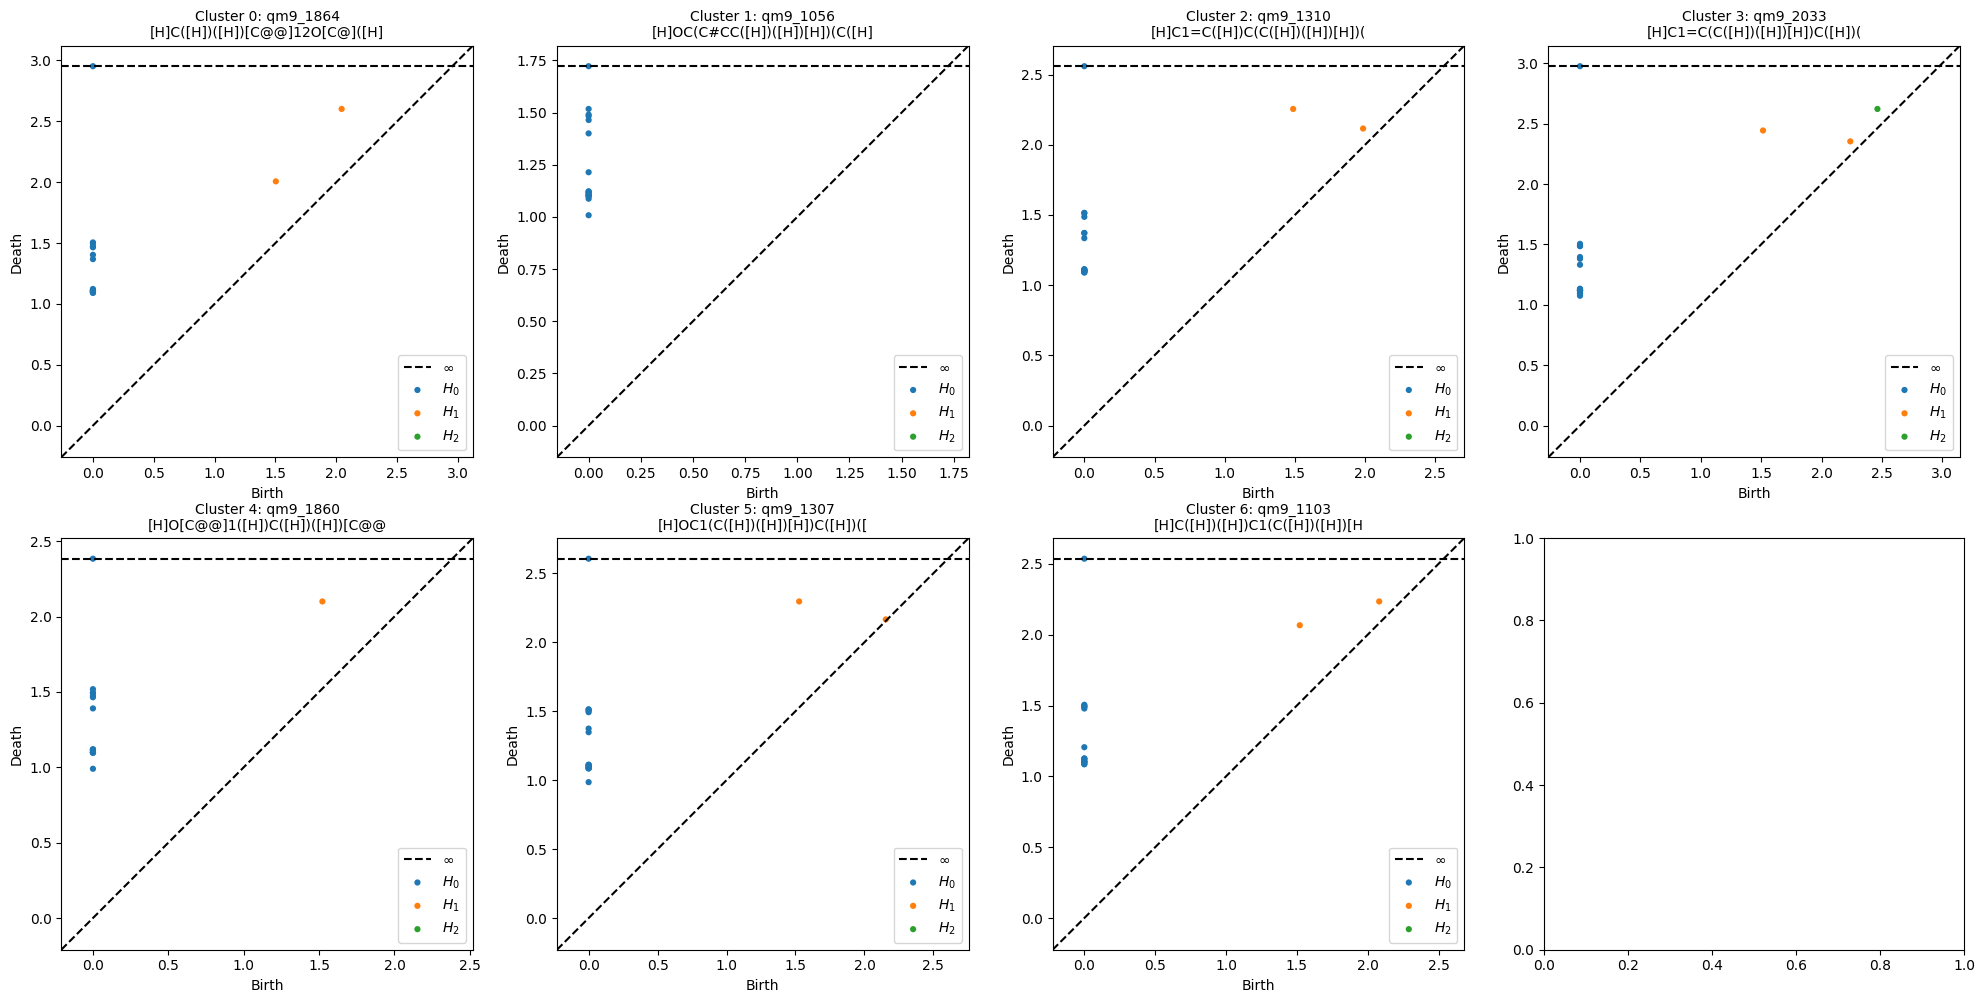

In [19]:
diagrams = PersistentHomology.compute_persistence_diagrams(frames)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

unique_clusters = sorted(isomers_df["cluster_ph"].unique().to_list())
n = 0

for i, cluster_nr in enumerate(unique_clusters):
    cluster_sample = isomers_df.with_row_index().filter(pl.col("cluster_ph") == cluster_nr).head(1)
    
    idx = cluster_sample["index"][n]
    mol_id = cluster_sample["mol_id"][n]
    smiles = cluster_sample["smiles"][n]
    
    dgms_dict = diagrams[idx]
    dgms = [dgms_dict.get(dim, np.empty((0, 2))) for dim in range(3)]
    
    plt.sca(axes[i])
    plot_diagrams(dgms, show=False)
    axes[i].set_title(f"Cluster {cluster_nr}: {mol_id}\n{smiles[:30]}", fontsize=10)



plt.tight_layout()
plt.show()


# SOAP

In [20]:
properties = {
    "UMAP 1": X_soap_t[:, 0],
    "UMAP 2": X_soap_t[:, 1],
    "Cluster": labels_soap,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…